# 8주차 정답 Notebook — 공정 이상과 원인 후보 찾기

## 1단계. 데이터 불러오기

In [1]:
import pandas as pd

df = pd.read_csv("../../data/weekly/week08/week08_anomaly_root_cause.csv")
df.head()

,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,진공도_mTorr,두께_nm,진동_mm_s,냉각수온도_섭씨,습도_pct,합격여부
0,2024-03-01 00:00,LOT-0404,EQ-02,식각,303.4,1017.3,4.92,104.66,0.682,19.52,47.4,1
1,2024-03-01 04:00,LOT-0094,EQ-04,증착,302.1,1016.5,5.12,100.03,0.472,20.90,50.4,1
2,2024-03-01 07:00,LOT-0408,EQ-02,증착,295.6,1018.4,5.24,98.62,0.636,19.00,45.7,-1
3,2024-03-01 22:00,LOT-0721,EQ-04,식각,298.4,1010.8,4.55,93.92,0.499,19.26,43.3,1
4,2024-03-02 08:00,LOT-0455,EQ-02,산화,300.1,1015.9,5.27,101.28,0.728,20.43,43.0,1


## 2단계. 진공도 정상 범위 이탈 데이터 찾기

In [2]:
vac_low, vac_high = 4.5, 5.5
vac_outlier = df[(df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)]
print("진공도 이탈 행 수:", len(vac_outlier))

진공도 이탈 행 수: 78


## 3단계. 진공도 이탈 여부에 따른 불합격률 비교

In [3]:
df["불합격여부_숫자"] = (df["합격여부"] == -1).astype(int)

is_out = (df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)
fail_in = df.loc[~is_out, "불합격여부_숫자"].mean() * 100
fail_out = df.loc[is_out, "불합격여부_숫자"].mean() * 100
print(f"정상 범위 안 불합격률: {fail_in:.2f}%")
print(f"정상 범위 밖 불합격률: {fail_out:.2f}%")

정상 범위 안 불합격률: 8.06%
정상 범위 밖 불합격률: 25.64%


**답**: 진공도 이탈은 불합격의 원인 후보로 볼 수 있다(실제 인과관계는 추가 검증 필요).

## 4단계. 온도와 두께의 관계

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49453 (\N{H

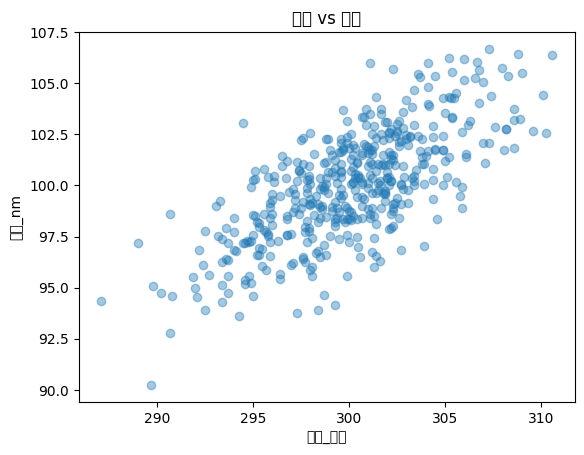

상관계수 r = 0.71


In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["온도_섭씨"], df["두께_nm"], alpha=0.4)
plt.xlabel("온도_섭씨"); plt.ylabel("두께_nm"); plt.title("온도 vs 두께")
plt.show()

r = df["온도_섭씨"].corr(df["두께_nm"])
print("상관계수 r =", round(r, 2))

## 5단계. 습도(대조군)와 불합격의 관계 확인하기

In [5]:
r_humid = df["습도_pct"].corr(df["불합격여부_숫자"])
print("습도-불합격 상관계수 r =", round(r_humid, 2))

습도-불합격 상관계수 r = -0.13


**답**: 습도의 상관계수는 0에 가까워 뚜렷한 관계가 없다. 이는 '관계가 없다'는 것도
정상적이고 의미 있는 분석 결과임을 보여준다(모든 변수가 불량과 관련 있는 것은 아니다).

## 6단계(도전). EQ-02의 진동 값 비교하기

In [6]:
df.groupby("설비번호")["진동_mm_s"].mean().round(3)

설비번호
EQ-01    0.507
EQ-02    0.678
EQ-03    0.503
EQ-04    0.501
Name: 진동_mm_s, dtype: float64

## 7단계. 오늘의 분석을 한 문장으로 정리하기

> 진공도가 정상 범위를 벗어나면 불합격률이 약 8.06%에서 25.64%로 높아지는 경향이 관찰되어,
> 진공도 이탈은 불합격의 원인 후보로 볼 수 있다. 다만 상관관계만으로 원인이라고 단정할 수 없으며,
> 정확한 원인 확인을 위해서는 추가 데이터와 실험이 필요하다.